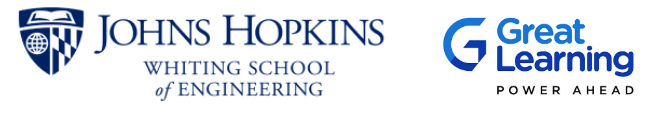

<font size=6>**Advanced RAG**</font>

<font size=5>**Multi-Modal RAG for Healthcare**</font>

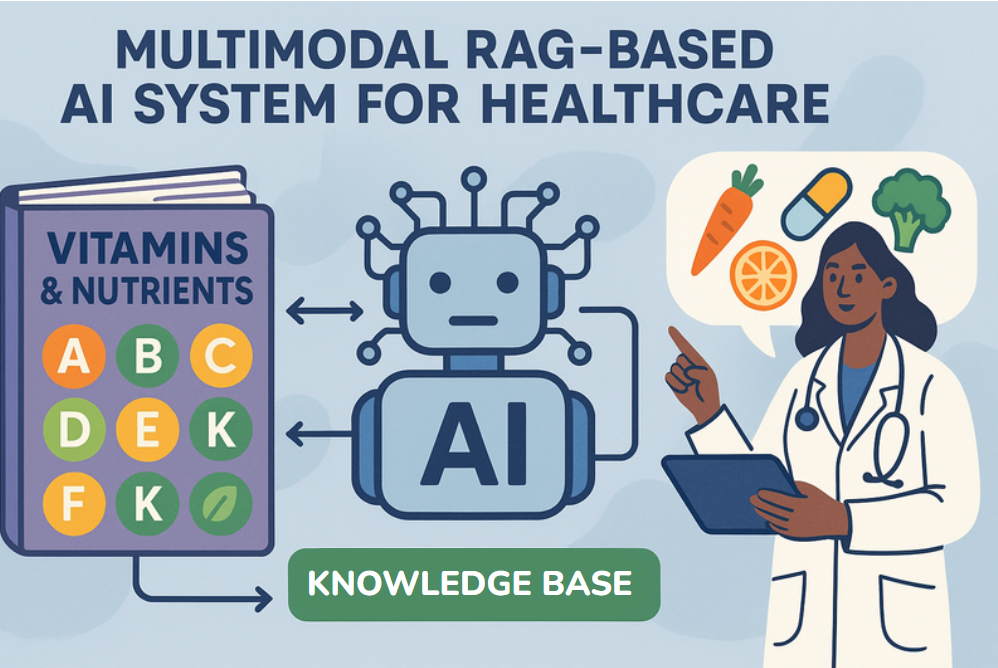

NutriWise is a small-scale Healthcare startup with a mission to spread knowledge and raise awareness about the essential vitamins and nutrients required for optimal human health. Recognizing the growing demand for personalized wellness solutions in today’s digital age, the company offers a variety of premium services, including personalized nutrition consultations and tailored diet plans. With the vision to leave a significant mark in the health and wellness sector, the leadership team brainstormed innovative ways to attract and engage potential customers.

During one of their board meetings, they conceived a groundbreaking idea: to launch a demo version of their services through an AI-powered system, which would be offered to users for free. This approach aims to convert these users into loyal customers who would eventually transition to their premium offerings.

The conceptualized AI system would enable users to ask questions regarding nutrition and health. Instead of consulting with a human nutritionist or dietitian, users could engage with the AI, which would generate tailored responses based on their queries. To enhance user experience, the AI would also provide relevant images that support the responses.

**Solution Approach**

The core of the solution involves the creation of an AI-based Advanced Retrieval-Augmented Generation (RAG) System that encompasses the following key components:

1. **Development of a Text and Image-Based Knowledge Base:** This will compile comprehensive information about vitamins and nutrients, supplemented with relevant images to enrich user understanding.
2. **Implementation of Reranking Methodology:** This process will refine the AI system’s ability to recommend the most relevant responses to user queries, thereby enhancing accuracy and user satisfaction.
3. **Query Expansion Techniques:** These will improve the AI’s comprehension of user queries, making it more efficient in providing precise information tailored to individual needs.

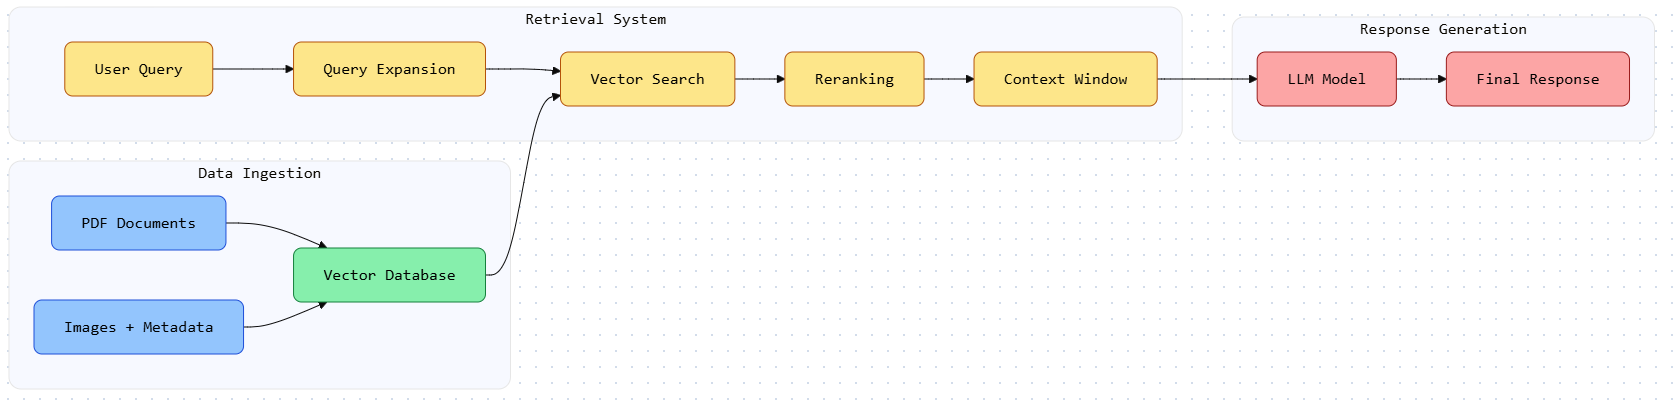

## **Setup**

In [23]:
# @title Run this cell => Restart the session => Start executing the below cells **(DO NOT EXECUTE THIS CELL AGAIN)**
'''
!pip install -q langchain==0.3.21 \
                huggingface_hub==0.29.3 \
                openai==1.68.2 \
                chromadb==0.6.3 \
                lark==1.2.2\
                rank_bm25==0.2.2\
                numpy==2.2.4 \
                scipy==1.15.2 \
                scikit-learn==1.6.1 \
                transformers==4.50.0 \
                markdown-pdf==1.7 \
                sentence_transformers==4.0.0 \
                torch==2.6.0+cu124  \



%pip install --upgrade chromadb
%pip install pillow
%pip install open-clip-torch
%pip install matplotlib
%pip install langchain-community
%pip install pypdf
'''

%pip install sentence-transformers
#%pip install langchain-openai==0.2.12

  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.0.1
    Uninstalling huggingface-hub-1.0.1:
      Successfully uninstalled huggingface-hub-1.0.1

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Unzipping the Research Papers
import zipfile
with zipfile.ZipFile("MLS14 - Adv RAG.zip", 'r') as zip_ref:
  zip_ref.extractall(".")

In [5]:
# @title Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [ ]:
# Run this cell after you have reached Stage 2
!pip install -U langchain-openai==0.2.12


In [6]:
# @title Defining the Embedding Model - Using `text-embedding-ada-002` Model
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

/Users/sneha/Documents/Code/JHU-Notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# @title Defining the LLM Model - Using `gpt-4o-mini` Model
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## **Step 1 : Loading the PDF and storing it in the vectorDB**


In [8]:
from langchain.document_loaders import PyPDFLoader

# Reading the NOFO Document
pdf_file = "MLS14 - Adv RAG/Vitamin_and_minerals.pdf"
pdf_loader = PyPDFLoader(pdf_file);
text_data = pdf_loader.load()

In [9]:
from langchain.vectorstores import Chroma

text_vectorstore = Chroma(
    collection_name="vitamin_and_minerals",
    embedding_function=embeddings)

text_vectorstore.add_documents(documents=text_data)

/var/folders/lx/sf3nk2f91gdg4grbl_m81_y00000gn/T/ipykernel_51816/3986546.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  text_vectorstore = Chroma(


['f8eb69fd-2e7c-4ae7-9014-b8fe0b61cd0d',
 '0d9075ba-dbf8-4a65-a159-f6596967ec82',
 '82e4a284-ce84-43ab-9433-6acdfd38f308',
 '137cec55-d302-4ed9-b3be-861631fb2366',
 '471dee53-5e51-4488-bb2d-af040f7d94ca',
 'a86a205a-1cf8-4a66-8026-60c71403d544',
 'a81f03ec-beda-4d9c-8afb-33feb5c07f6f',
 'c4146c32-b6aa-4352-8501-55185e9c0ead',
 '84789f0c-9784-4a71-a0c5-6a000ac4e788',
 '66c3902b-ad38-4cdf-98ed-5715f536f91f',
 '48e206f8-2770-4904-993a-cbd64407e696',
 '454f933d-9495-423f-9e73-054d29485c8f',
 '9a893d8f-15c8-4502-8507-1248534ae9d3',
 '7a01779f-650a-4ca6-8f78-dcb5f200ad7c',
 'c24b98ad-91e0-46a1-bacc-d3b953f76029',
 '177d3a16-a9c2-4ff6-9ea6-7ac7973cff4e',
 '350f27d4-c26c-4320-9fac-9dfd133ee861',
 '7391001b-bb82-47e7-aab8-b5956413564f',
 '0c52ddfd-0d5c-432f-ada7-22796432324a',
 '10f1ea97-d136-4680-857d-8c3ee23e59dd',
 'b1588cfc-8154-427d-864f-c491caf083ee',
 '4b2dae45-507e-411c-9517-1ad174565330',
 'ddff97ed-11a7-4dd3-af2b-81876c80743a',
 'f78a59d1-ce8e-4b73-8069-3e5791290de7',
 'd5012623-0cee-

In [10]:
vanilla_retriever = text_vectorstore.as_retriever(search_kwargs={"k": 10}) # Number of relevant documents to retrieve

## **Step 2 : Loading the Images along with metadata and storing them in the vectorDB**

In [11]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from matplotlib import pyplot as plt
import os

In [12]:
# Create database file at folder "my_vectordb" or load into client if exists
chroma_client = chromadb.PersistentClient(path="my_vectordb")

# Instantiate image loader helper
image_loader = ImageLoader()

# Instantiate multimodal embedding function
image_embedding_function = OpenCLIPEmbeddingFunction()

# Create the collection, aka vector database. Or, if database already exist, then use it. Specify the model that we want to use to do the embedding
multimodal_db = chroma_client.get_or_create_collection(name="multimodal_db", embedding_function=image_embedding_function, data_loader=image_loader)

In [13]:
multimodal_db.count()

0

In [15]:
from PIL import Image
import numpy as np

image_paths = [f"MLS14 - Adv RAG/sources/{file}" for file in os.listdir("MLS14 - Adv RAG/sources")]
image_paths

['MLS14 - Adv RAG/sources/VitaminD-1.png',
 'MLS14 - Adv RAG/sources/VitaminD-3.png',
 'MLS14 - Adv RAG/sources/VitaminD-2.png',
 'MLS14 - Adv RAG/sources/VitaminA-4.png',
 'MLS14 - Adv RAG/sources/VitaminA-5.png',
 'MLS14 - Adv RAG/sources/VitaminC-3.png',
 'MLS14 - Adv RAG/sources/VitaminA-1.png',
 'MLS14 - Adv RAG/sources/VitaminC-2.png',
 'MLS14 - Adv RAG/sources/VitaminA-2.png',
 'MLS14 - Adv RAG/sources/VitaminA-3.png',
 'MLS14 - Adv RAG/sources/VitaminC-1.png']

In [16]:
# Defining Metadata
Metadata = []
for file in os.listdir("MLS14 - Adv RAG/sources"):
  Metadata.append({'Vitamin':file.split("-")[0][-1],
                   'info': f'The images shows the sources of Vitamin {file.split("-")[0][-1]}'})

Metadata

[{'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'D', 'info': 'The images shows the sources of Vitamin D'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'A', 'info': 'The images shows the sources of Vitamin A'},
 {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'}]

In [17]:
# Use .add() to add a new record or .update() to update existing record
multimodal_db.add(
    ids=[str(x) for x in range(len(os.listdir("MLS14 - Adv RAG/sources")))],
    uris = image_paths,
    metadatas=Metadata
)

In [18]:
multimodal_db.count()

11

In [19]:
# Simple function to print the results of a query.
# The 'results' is a dict {ids, distances, data, ...}
# Each item in the dict is a 2d list.
def print_query_results(query_list: list, query_results: dict)->None:
    result_count = len(query_results['ids'][0])

    for i in range(len(query_list)):
        for j in range(result_count):
            id       = query_results["ids"][i][j]
            distance = query_results['distances'][i][j]
            data     = query_results['data'][i][j]
            document = query_results['documents'][i][j]
            metadata = query_results['metadatas'][i][j]
            uri      = query_results['uris'][i][j]

            print(f'id: {id}, distance: {distance}, metadata: {metadata}, document: {document}')

            # Display image, the physical file must exist at URI.
            # (ImageLoader loads the image from file)
            print(f'data: {uri}')
            plt.imshow(data)
            plt.axis("off")
            plt.show()

In [20]:
def get_image(query_texts):
# Query vector db
    query_results = multimodal_db.query(
        query_texts = query_texts,
        n_results=2,
        include=['documents', 'distances', 'metadatas', 'data', 'uris'],
    )

    print_query_results(query_texts, query_results)

id: 10, distance: 0.7099936604499817, metadata: {'info': 'The images shows the sources of Vitamin C', 'Vitamin': 'C'}, document: None
data: MLS14 - Adv RAG/sources/VitaminC-1.png


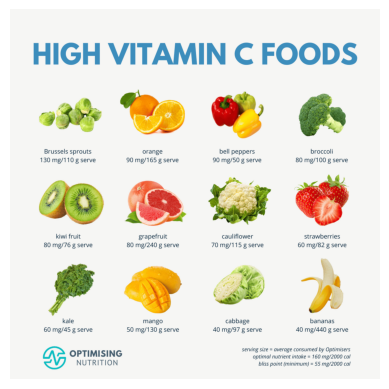

id: 7, distance: 0.7135545611381531, metadata: {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'}, document: None
data: MLS14 - Adv RAG/sources/VitaminC-2.png


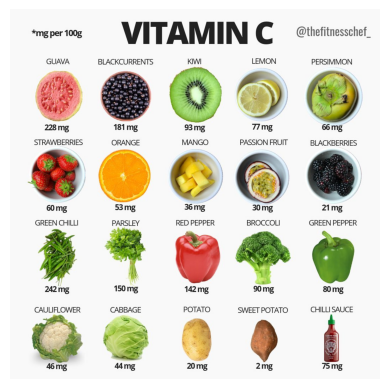

In [21]:
get_image(['Citrus fruits have which common vitamins'])

## **Reranking**

In [ ]:
#!pip install sentence-transformers
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
crossencoder = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.29.3
    Uninstalling huggingface-hub-0.29.3:
      Successfully uninstalled huggingface-hub-0.29.3

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pickle
with open("crossencoder.pkl", "wb") as f: # Save the crossencoder model
    pickle.dump(crossencoder, f)


In [27]:
# Check your langchain version
import langchain
print(f"LangChain version: {langchain.__version__}")

# Check available modules
import langchain_community
print(f"LangChain Community version: {langchain_community.__version__}")

LangChain version: 0.3.21
LangChain Community version: 0.3.20


In [28]:
import pickle

# Load cross-encoder from pickle file
with open('crossencoder.pkl', 'rb') as f:
    crossencoder = pickle.load(f)

# Verify it loaded
print(f"Cross-encoder loaded: {type(crossencoder)}")
print(f"Model: {crossencoder}")

Cross-encoder loaded: <class 'langchain_community.cross_encoders.huggingface.HuggingFaceCrossEncoder'>
Model: client=CrossEncoder(
  (model): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 384, padding_idx=0)
        (position_embeddings): Embedding(512, 384)
        (token_type_embeddings): Embedding(2, 384)
        (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-5): 6 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
     

In [30]:
from langchain_core.documents import Document
from langchain.retrievers.document_compressors.base import BaseDocumentCompressor
from typing import Sequence, List, Any

class CustomCrossEncoderReranker(BaseDocumentCompressor):
    model: Any
    top_n: int = 5

    def compress_documents(
        self,
        documents: Sequence[Document],
        query: str,
        **kwargs  # 👈 catch callbacks etc.
    ) -> List[Document]:
        """Rerank documents using cross-encoder model."""
        if not documents:
            return []

        # Prepare query–document pairs
        pairs = [[query, doc.page_content] for doc in documents]

        # Score with your cross-encoder
        scores = self.model.score(pairs)

        # Sort by score (highest first)
        doc_scores = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)

        # Return top_n documents
        return [doc for doc, _ in doc_scores[:self.top_n]]



# Use your existing crossencoder
reranker = CustomCrossEncoderReranker(model=crossencoder, top_n=5)

In [31]:
import langchain, langchain_core, langchain_community
print("LangChain:", langchain.__version__)
print("LangChain Core:", langchain_core.__version__)
print("LangChain Community:", langchain_community.__version__)

LangChain: 0.3.21
LangChain Core: 0.3.79
LangChain Community: 0.3.20


In [ ]:
!pip install -U langchain==0.3.27 langchain-core==0.3.72 langchain-community==0.3.27


###### **Stage 2** ######
If you get an error after this stage in the next cell, then:

You might need to restart the session and need to re-run  certain cells covered in the beginning, especially the cell which installs compatible version of langchain-openai. You might need to run the Config cell for API keys as well

In [32]:
from langchain.retrievers import ContextualCompressionRetriever
reranker_retriever = ContextualCompressionRetriever(
    base_compressor=reranker, base_retriever=vanilla_retriever
)

## **User Query Expansion**

In [33]:
# Query Expansion for User_query

def query_expansion(user_query):
    query_enhancement = f"""
    You are an expert in information retrieval systems, particularly skilled in enhancing queries for document search efficiency.
    Perform query expansion on the received question by considering alternative phrasings or synonyms commonly used in document retrieval contexts.
    If there are multiple ways to phrase the user's question or common synonyms for key terms, provide several reworded versions.

    If there are acronyms or words you are not familiar with, do not try to rephrase them.

    Return at least 3 versions of the question as a list.
    Generate only a list of questions. Do not mention anything before or after the list.

    Question:
    {user_query}
    """


    new_question = llm.invoke(query_enhancement)
    return (new_question.content)

## **Step 3 : Retriever which can fetch the data from (PDF + Images) and return this to the user**

In [34]:
user_query = "What are the benefits of vitamin C & vitamin A"

In [35]:
# Query Expansion
multipule_queries = query_expansion(user_query)
print(multipule_queries)

1. What advantages do vitamin C and vitamin A offer?
2. What are the health benefits associated with vitamin C and vitamin A?
3. How do vitamin C and vitamin A contribute to overall health?


In [37]:
# Calling the vanilla retriever
vanilla_responses = vanilla_retriever.get_relevant_documents(multipule_queries)

# We can see the results are not sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in vanilla_responses]
print(context_query_pairs_for_scoring)
crossencoder.score(context_query_pairs_for_scoring)

[['1. What advantages do vitamin C and vitamin A offer?\n2. What are the health benefits associated with vitamin C and vitamin A?\n3. How do vitamin C and vitamin A contribute to overall health?', 'VITAMIN AND MINERAL REQUIREMENTS IN HUMAN NUTRITION\n134\nClaims for a positive association between vitamin C consumption and\nhealth status are frequently made, but results from intervention studies are\ninconsistent. Low plasma concentrations are reported in patients with dia-\nbetes (47) and infections ( 48) and in smokers ( 49), but the relative contribu-\ntion of diet and stress to these situations is uncertain (see Chapter 8 on\nantioxidants). Epidemiological studies indicate that diets with a high vitamin\nC content have been associated with lower cancer risk, especially for cancers\nof the oral cavity, oesophagus, stomach, colon, and lung (39, 50–52). However,\nthere appears to be no effect of consumption of vitamin C supplements on\nthe development of colorectal adenoma and stomach 

array([-1.9031544, -3.003903 , -4.478505 , -6.1253557, -4.3956428,
       -5.3037276, -4.974593 , -1.0987068, -2.6063886, -5.946724 ],
      dtype=float32)

**In the above cell, we can observe that we fetched 10 chunks and they are not sorted. Now, we will be following the re-ranking approach to fetch the 5 most relevant chunks from these 10.**

In [38]:
# Calling the reranking retriever
reranked_responses = reranker_retriever.get_relevant_documents(multipule_queries)

In [39]:
# We can see the results are sorted
context_query_pairs_for_scoring = [[multipule_queries, doc_text.page_content] for doc_text in reranked_responses]
crossencoder.score(context_query_pairs_for_scoring)

array([-1.0987068, -1.9031544, -2.6063886, -3.003903 , -4.3956428],
      dtype=float32)

In [40]:
prompt = f"""
You are an expert AI assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.

### Context:
{reranked_responses}

### Question:
{multipule_queries}
"""

In [41]:
llm_response = llm.invoke(prompt)

Answer: 
 ### Advantages and Health Benefits of Vitamin C and Vitamin A

1. **Advantages of Vitamin C:**
   - **Antioxidant Properties:** Vitamin C acts as an electron donor, functioning as a reducing agent and antioxidant, which helps protect cells from oxidative stress.
   - **Enzymatic Functions:** It is essential for the activity of several enzymes involved in collagen synthesis, carnitine biosynthesis, and the metabolism of certain neurotransmitters.
   - **Immune Function:** Vitamin C supports the immune system, potentially reducing the duration and severity of infections.

2. **Health Benefits Associated with Vitamin C:**
   - **Cancer Risk Reduction:** Epidemiological studies suggest that high vitamin C intake is associated with a lower risk of certain cancers, including those of the oral cavity, esophagus, stomach, colon, and lung.
   - **Cardiovascular Health:** There is some evidence linking vitamin C status with reduced risk of cardiovascular diseases, although results from

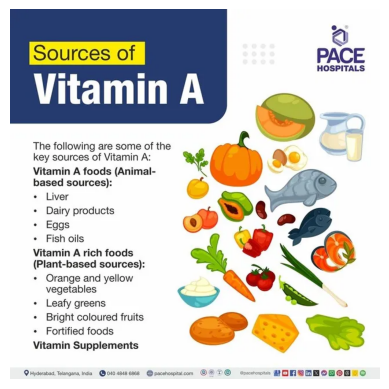

id: 10, distance: 0.6993288993835449, metadata: {'Vitamin': 'C', 'info': 'The images shows the sources of Vitamin C'}, document: None
data: MLS14 - Adv RAG/sources/VitaminC-1.png


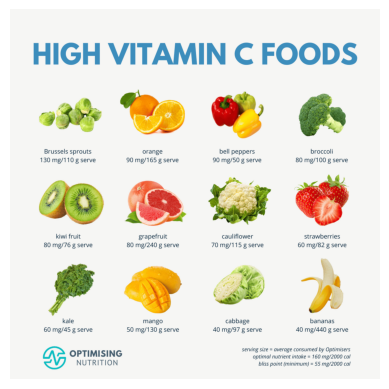

In [42]:
print("Answer: \n", llm_response.content)
print("="*50)
print("Relevant Images: \n")
get_image([llm_response.content])

**Note :** To improve the accuracy of retrieving relevant images, it's important to increase the number of images in the database the more images available, the better the system can identify and return relevant results.

## **Further Enhancement**
> Deploy the same application on the Gradio

In [43]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 6.1 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 6.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 861.5/861.5 kB 5.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 6.8 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: pillow
    Found existing installation: pillow 12.0.0━━━━━━━━━━━━━━━━━━━━  6/13 [pillow]
    Uninstalling pillow-12.0.0:╺━━━━━━━━━━━━━━━━━━━━━  6/13 [pillow]
      Successfully uninstalled pillow-12.0.0━━━━━━━━━━━━━━━━━━  6/13 [pillow]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [gradio]12/13 [gradio]client]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [45]:
import gradio as gr

def predict(user_query):

    # Query Expansion
    multipule_queries = query_expansion(user_query)

    # Reranking
    reranked_responses = reranker_retriever.get_relevant_documents(multipule_queries)

    prompt = f"""
    You are an expert AI assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer the question.

    ### Context:
    {reranked_responses}

    ### Question:
    {multipule_queries}
    """

    # Fetching Text
    llm_response = llm.invoke(prompt)

    # Fetching Images
    rel_img = multimodal_db.query(
        query_texts = llm_response.content,
        n_results=2,
        include=['uris'],
    )

    return llm_response.content, rel_img['uris'][0] # Return both text and image paths


iface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter your query"),
    outputs=[gr.Markdown(label= "Answer"), gr.Gallery(label="Relevant Images")],  # Using Gallery for images
    title="NutriWise AI Assistant",
    description="Ask questions about nutrition and health"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Sneha note: If images returned are not correct or accurate, the embedding model for the images is not working well and needs to be improved/replaced.

Solution:
https://zilliz.com/learn/explore-colbert-token-level-embedding-and-ranking-model-for-similarity-search

*ColBERT embdeddings* - supports multi-vector embeddings. 
Short for Contextualized Late Interaction over BERT, marks a paradigm shift from traditional embedding models like BERT. Unlike BERT, which consolidates token vectors into a singular representation, ColBERT maintains per-token representations, offering a finer granularity in similarity calculation. What sets ColBERT apart is its introduction of a novel late interaction mechanism, a term we'll elaborate on shortly for query-document similarity comparisons. This mechanism enables efficient and precise ranking and retrieval by handling queries and documents separately until the final stages of the retrieval process.